# Test PP(XW) for draws from a Cauchy / uniform / Pareto distributions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Draw 1,000,000 samples from a standard Cauchy distribution
samples = np.random.standard_cauchy(1000000)

# Truncate the distribution for better plotting
samples = samples[(samples > -25) & (samples < 25)]

# Plot the histogram of the samples
plt.hist(samples, bins=100)
plt.show()

In [ ]:
d = 10
samples = np.random.standard_cauchy(d)
print(samples)

In [5]:
for i in range(10):
    print(np.random.uniform(0.1,5.0))

0.8845084581725264
1.6820934636336444
4.09748471542953
4.968438721508707
0.7253183619344692
0.45339011737778123
4.158223860881919
1.774319897486807
3.7874337550940202
1.9734911558013224


In [6]:
N = 1000
d = 500
alpha = 2.0

uniform_draws = False

this_random = np.random.randint(0, 3)
use_pareto = this_random == 0
use_uniform = this_random == 1
use_cauchy = this_random == 2
alpha = np.random.uniform(0.1,5.0)
X = pp.generate_data_manifold(N, 
                              d, 
                              alpha, 
                              uniform_draws,
                              use_pareto,
                              use_uniform,
                              use_cauchy)
print(X.shape)

this_random = np.random.randint(0, 3)
use_pareto = this_random == 0
use_uniform = this_random == 1
use_cauchy = this_random == 2
alpha = np.random.uniform(0.1,5.0)
W = pp.generate_square_weight_matrix(d, 
                                     alpha, 
                                     uniform_draws,
                                     use_pareto,
                                     use_uniform,
                                     use_cauchy)
#print(W.shape)

pp_dim_X = pp.calculate_PatnaikPearson_dim(X)
dim_X = X.shape[1]
nu_over_d_X = pp_dim_X / dim_X
print("pp_dim_X = ", pp_dim_X)
pp_dim_W = pp.calculate_PatnaikPearson_dim(W)
dim_W = W.shape[1]
nu_over_d_W = pp_dim_W / dim_W
print("pp_dim_W = ", pp_dim_W)

XW = X @ W
pp_dim_XW = pp.calculate_PatnaikPearson_dim(XW)
dim_XW = XW.shape[1]
nu_over_d_XW = pp_dim_XW / dim_XW
print("pp_dim_XW = ", pp_dim_XW)

print("nu_over_d_XW = ", nu_over_d_XW)
print("min(nu_over_d_X, nu_over_d_W) = ", min(nu_over_d_X, nu_over_d_W))
print("nu_over_d_X * nu_over_d_W = ", nu_over_d_X * nu_over_d_W)


(1000, 500)
these_sigmas[0:5] =  [13.55433358  2.51859635 12.88758578  1.6937399   3.33322349]
 ** generate_square_weight_matrix: using GPU **
(500, 500)
pp_dim_X =  2.2432665335769695
pp_dim_W =  1.6251208494489116
pp_dim_XW =  1.1264270400834175
nu_over_d_XW =  0.0022528540801668353
min(nu_over_d_X, nu_over_d_W) =  0.003250241698897823
nu_over_d_X * nu_over_d_W =  1.4582316858347677e-05


In [44]:
N = 2000
d = 1000
num_iterations = 100
nu_over_d_XW_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    results_dict = product_experiment(N,d)
    nu_over_d_XW = results_dict["nu_over_d_XW"]
    upper_bound = results_dict["upper_bound"]
    lower_bound = results_dict["lower_bound"]
    print(i, lower_bound, nu_over_d_XW, upper_bound)

    nu_over_d_XW_vals[i] = nu_over_d_XW
    upper_bound_vals[i] = upper_bound
    lower_bound_vals[i] = lower_bound

these_sigmas[0:5] =  [1.0091265  1.07587837 1.24045742 2.58988724 1.46099081]
 ** generate_square_weight_matrix: using GPU **
0 0.6205862463474235 0.6306492767162101 0.6720697420045365
these_sigmas[0:5] =  [1.36034992 8.65304445 2.87704227 2.48231008 1.4126737 ]
 ** generate_square_weight_matrix: using GPU **
1 0.007303560461286427 0.009681221127314149 0.010789331238181876
these_sigmas[0:5] =  [-0.52126486 17.52075622 -0.13783951  0.06218516  0.82957083]
 ** generate_square_weight_matrix: using GPU **
2 0.00012969114681334016 0.00270828634544823 0.0031561157466469068
these_sigmas[0:5] =  [ 0.69985635  1.83120234 -6.25708584 -0.18629292 -5.57541231]
 ** generate_square_weight_matrix: using GPU **
3 0.02120466458133846 0.028432941547438743 0.03153287242218011
these_sigmas[0:5] =  [23.08526594  7.88513747 14.20694718 61.59391236  2.60641033]
 ** generate_square_weight_matrix: using GPU **
4 8.087804334722187e-05 0.0011649622863411648 0.0012730004764349631
these_sigmas[0:5] =  [1.08198454 

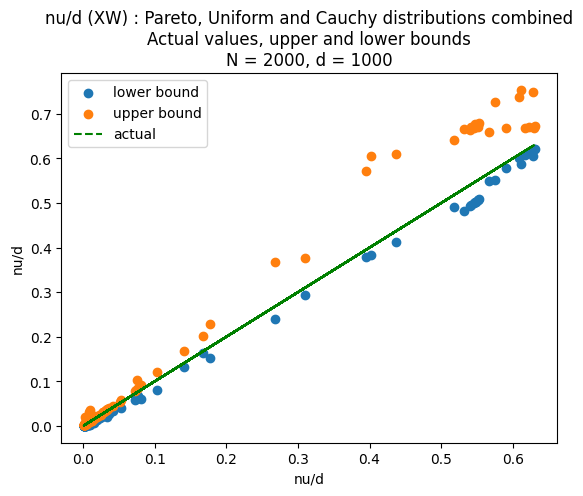

In [45]:
#this_title = "nu/d for product XW : actual, upper and lower bounds"
#this_title += "\nN = " + str(N) + ", d = " + str(d)

this_title = "nu/d (XW) : Pareto, Uniform and Cauchy distributions combined\nActual values, upper and lower bounds"
this_title += "\nN = " + str(N) + ", d = " + str(d)
plt.scatter(nu_over_d_XW_vals, lower_bound_vals, label = "lower bound")
plt.scatter(nu_over_d_XW_vals, upper_bound_vals, label = "upper bound")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle = "--", color = "green", label = "actual")
plt.xlabel("nu/d")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_XW_upper_lower_bounds.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Pareto

In [30]:
N = 2000
d = 1000
num_iterations = 100
nu_over_d_XW_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

force_pareto = True
pareto_uniform_draws = True
force_uniform = False
force_cauchy = False

for i in range(num_iterations):
    results_dict = product_experiment(N, d, force_pareto, pareto_uniform_draws, force_uniform, force_cauchy)
    nu_over_d_XW = results_dict["nu_over_d_XW"]
    upper_bound = results_dict["upper_bound"]
    lower_bound = results_dict["lower_bound"]
    print(i, lower_bound, nu_over_d_XW, upper_bound)

    nu_over_d_XW_vals[i] = nu_over_d_XW
    upper_bound_vals[i] = upper_bound
    lower_bound_vals[i] = lower_bound

these_sigmas[0:5] =  [1.00020266 1.00040557 1.00060872 1.00081212 1.00101576]
 ** generate_square_weight_matrix: using GPU **
0 0.007278096811469134 0.00760947824775322 0.007734184445949788
these_sigmas[0:5] =  [1.00030785 1.00061611 1.00092476 1.00123383 1.0015433 ]
 ** generate_square_weight_matrix: using GPU **
1 0.5452182965670817 0.5585636647877795 0.649206690364063
these_sigmas[0:5] =  [1.00023449 1.00046927 1.00070435 1.00093971 1.00117537]
 ** generate_square_weight_matrix: using GPU **
2 0.7103927847962238 0.7167404192322198 0.7747610811522443
these_sigmas[0:5] =  [1.00022805 1.00045637 1.00068498 1.00091387 1.00114304]
 ** generate_square_weight_matrix: using GPU **
3 0.4558547042069169 0.4622977490067792 0.4942910575943821
these_sigmas[0:5] =  [1.00091329 1.00182834 1.00274513 1.00366369 1.00458401]
 ** generate_square_weight_matrix: using GPU **
4 0.04442546226078374 0.04967563128441267 0.05466343727030203
these_sigmas[0:5] =  [1.0009568  1.00191548 1.00287603 1.00383848 1.

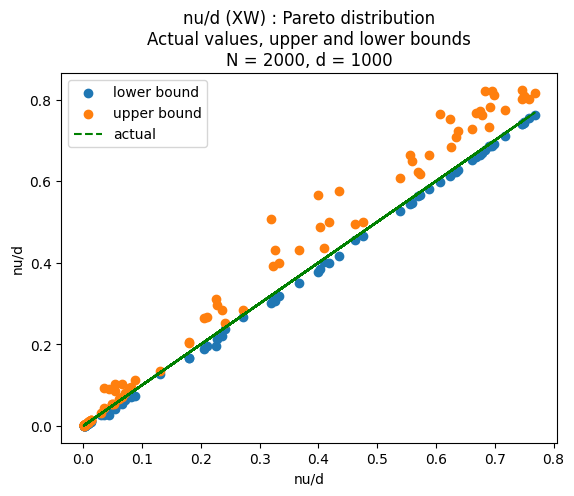

In [35]:
this_title = "nu/d (XW) : Pareto distribution\nActual values, upper and lower bounds"
this_title += "\nN = " + str(N) + ", d = " + str(d)
plt.scatter(nu_over_d_XW_vals, lower_bound_vals, label = "lower bound")
plt.scatter(nu_over_d_XW_vals, upper_bound_vals, label = "upper bound")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle = "--", color = "green", label = "actual")
plt.xlabel("nu/d")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_XW_pareto_actual_upper_lower_bounds.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Uniform - not much to see here

In [36]:
N = 2000
d = 1000
num_iterations = 20
nu_over_d_XW_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

force_pareto = False
pareto_uniform_draws = False
force_uniform = True
force_cauchy = False

for i in range(num_iterations):
    results_dict = product_experiment(N, d, force_pareto, pareto_uniform_draws, force_uniform, force_cauchy)
    nu_over_d_XW = results_dict["nu_over_d_XW"]
    upper_bound = results_dict["upper_bound"]
    lower_bound = results_dict["lower_bound"]
    print(i, lower_bound, nu_over_d_XW, upper_bound)

    nu_over_d_XW_vals[i] = nu_over_d_XW
    upper_bound_vals[i] = upper_bound
    lower_bound_vals[i] = lower_bound

these_sigmas[0:5] =  [0.81973769 0.4844691  0.53794357 0.53615391 0.6160647 ]
 ** generate_square_weight_matrix: using GPU **
0 0.5069833779457521 0.5502587666252119 0.6688924789115747
these_sigmas[0:5] =  [0.88457394 0.22935037 0.34353556 0.47182959 0.08246631]
 ** generate_square_weight_matrix: using GPU **
1 0.5024820353100868 0.5487922045163488 0.6787853782350826
these_sigmas[0:5] =  [0.87294549 0.7659788  0.33084388 0.18044168 0.45906374]
 ** generate_square_weight_matrix: using GPU **
2 0.5084060491629783 0.55198888595239 0.6769309008144627
these_sigmas[0:5] =  [0.44759609 0.81514137 0.38205953 0.66950601 0.65695086]
 ** generate_square_weight_matrix: using GPU **
3 0.5070743034695558 0.5513202742858244 0.6667994010684342
these_sigmas[0:5] =  [0.52421084 0.51636471 0.51140063 0.64978233 0.67108249]
 ** generate_square_weight_matrix: using GPU **
4 0.5061001716250926 0.5507389178918942 0.6749892276746172
these_sigmas[0:5] =  [0.27668841 0.47842834 0.3002344  0.40151006 0.40019891]

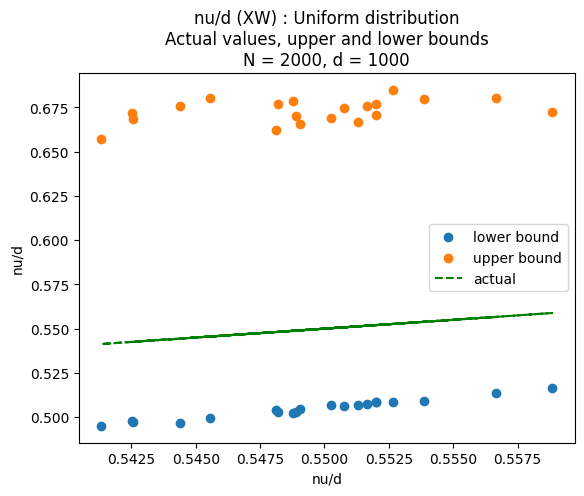

In [39]:
this_title = "nu/d (XW) : Uniform distribution\nActual values, upper and lower bounds"
this_title += "\nN = " + str(N) + ", d = " + str(d)
plt.scatter(nu_over_d_XW_vals, lower_bound_vals, label = "lower bound")
plt.scatter(nu_over_d_XW_vals, upper_bound_vals, label = "upper bound")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle="--", color = "green", label = "actual")
plt.xlabel("nu/d")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_XW_uniform_upper_lower_bounds.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Cauchy

In [40]:
N = 2000
d = 1000
num_iterations = 100
nu_over_d_XW_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

force_pareto = False
pareto_uniform_draws = False
force_uniform = False
force_cauchy = True

for i in range(num_iterations):
    results_dict = product_experiment(N, d, force_pareto, pareto_uniform_draws, force_uniform, force_cauchy)
    nu_over_d_XW = results_dict["nu_over_d_XW"]
    upper_bound = results_dict["upper_bound"]
    lower_bound = results_dict["lower_bound"]
    print(i, lower_bound, nu_over_d_XW, upper_bound)

    nu_over_d_XW_vals[i] = nu_over_d_XW
    upper_bound_vals[i] = upper_bound
    lower_bound_vals[i] = lower_bound

these_sigmas[0:5] =  [-2.55971188 -8.51319228 -0.95772526 -0.42167373  2.05086005]
 ** generate_square_weight_matrix: using GPU **
0 0.00011579062733286213 0.0028666484573628584 0.004014145286501879
these_sigmas[0:5] =  [ 1.81763384 -3.71204098 -0.11567964  0.270753   -0.19289057]
 ** generate_square_weight_matrix: using GPU **
1 0.00021554664687291943 0.0025643639215692064 0.014391773266501104
these_sigmas[0:5] =  [-11.09894258   0.75790802   0.12821884  -0.43343347  -1.65543509]
 ** generate_square_weight_matrix: using GPU **
2 4.4733341669692715e-05 0.001868370643945707 0.005006205169461198
these_sigmas[0:5] =  [  0.30369866 -21.78556218  -1.52905762   1.82880478   1.08125239]
 ** generate_square_weight_matrix: using GPU **
3 0.0002637853750725873 0.0029288022480880587 0.005660216951732305
these_sigmas[0:5] =  [ 0.63567038  0.00345059 -1.50829004 -1.52899457  1.74640794]
 ** generate_square_weight_matrix: using GPU **
4 0.00028241591112945015 0.0024981742270204824 0.0046088070996178

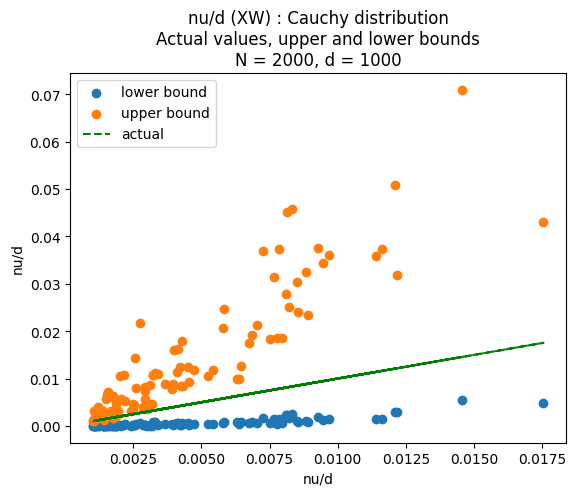

In [43]:
this_title = "nu/d (XW) : Cauchy distribution\nActual values, upper and lower bounds"
this_title += "\nN = " + str(N) + ", d = " + str(d)
plt.scatter(nu_over_d_XW_vals, lower_bound_vals, label = "lower bound")
plt.scatter(nu_over_d_XW_vals, upper_bound_vals, label = "upper bound")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle="--", color = "green", label = "actual")
plt.xlabel("nu/d")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_XW_cauchy_upper_lower_bounds.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
def product_experiment(N : int, 
                       d : int, 
                       force_pareto : bool = False, 
                       #pareto_alpha : float,
                       pareto_uniform_draws : bool = False,
                       force_uniform : bool = False,
                       force_cauchy : bool = False
                      ) -> dict:

    uniform_draws = False

    this_random = np.random.randint(0, 3)
    use_pareto = this_random == 0
    use_uniform = this_random == 1
    use_cauchy = this_random == 2
    alpha = np.random.uniform(0.1,5.0)

    if force_pareto:
        use_pareto = True
        uniform_draws = pareto_uniform_draws 
        use_uniform = False
        use_cauchy = False
    elif force_uniform:
        use_pareto = False
        use_uniform = True
        use_cauchy = False
    elif force_cauchy:
        use_pareto = False
        use_uniform = False
        use_cauchy = True
    
    X = pp.generate_data_manifold(N, 
                              d, 
                              alpha, 
                              uniform_draws,
                              use_pareto,
                              use_uniform,
                              use_cauchy)
    #print(X.shape)

    this_random = np.random.randint(0, 3)
    use_pareto = this_random == 0
    use_uniform = this_random == 1
    use_cauchy = this_random == 2
    alpha = np.random.uniform(0.1,5.0)

    if force_pareto:
        use_pareto = True
        uniform_draws = pareto_uniform_draws 
        use_uniform = False
        use_cauchy = False
    elif force_uniform:
        use_pareto = False
        use_uniform = True
        use_cauchy = False
    elif force_cauchy:
        use_pareto = False
        use_uniform = False
        use_cauchy = True
            
    W = pp.generate_square_weight_matrix(d, 
                                     alpha, 
                                     uniform_draws,
                                     use_pareto,
                                     use_uniform,
                                     use_cauchy)
    #print(W.shape)

    pp_dim_X = pp.calculate_PatnaikPearson_dim(X)
    dim_X = X.shape[1]
    nu_over_d_X = pp_dim_X / dim_X
    #print("pp_dim_X = ", pp_dim_X)
    pp_dim_W = pp.calculate_PatnaikPearson_dim(W)
    dim_W = W.shape[1]
    nu_over_d_W = pp_dim_W / dim_W
    #print("pp_dim_W = ", pp_dim_W)

    XW = X @ W
    pp_dim_XW = pp.calculate_PatnaikPearson_dim(XW)
    dim_XW = XW.shape[1]
    nu_over_d_XW = pp_dim_XW / dim_XW
    #print("pp_dim_XW = ", pp_dim_XW)

    #print("nu_over_d_XW = ", nu_over_d_XW)
    #print("min(nu_over_d_X, nu_over_d_W) = ", 
    upper_bound = min(nu_over_d_X, nu_over_d_W)
    #print("nu_over_d_X * nu_over_d_W = ", 
    lower_bound = nu_over_d_X * nu_over_d_W

    results_dict = {
        "nu_over_d_XW" : nu_over_d_XW,
        "upper_bound" : upper_bound,
        "lower_bound" : lower_bound
    }

    return results_dict